In [1]:
!unzip Telco_customer_churn.zip

Archive:  /content/Telco_customer_churn.zip
  inflating: Telco_customer_churn.csv  


### Importing

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , MinMaxScaler
from sklearn.metrics import classification_report , ConfusionMatrixDisplay , PrecisionRecallDisplay , RocCurveDisplay
from keras.models import Sequential
from keras.layers import Input , Dense , Dropout
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping

### Loading Data

In [39]:
df = pd.read_csv(filepath_or_buffer = "Telco_customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### EDA

In [40]:
df.shape

(7043, 21)

In [41]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
df.isnull().sum().sum()

np.int64(0)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [45]:
df = df.drop(columns = ["customerID"])

In [46]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"] , errors = "coerce")
df = df.dropna(subset = ["TotalCharges"])

In [47]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


In [48]:
df.describe(include = ["object"]).T

,count,unique,top,freq
gender,7032,2,Male,3549
Partner,7032,2,No,3639
Dependents,7032,2,No,4933
PhoneService,7032,2,Yes,6352
MultipleLines,7032,3,No,3385
InternetService,7032,3,Fiber optic,3096
OnlineSecurity,7032,3,No,3497
OnlineBackup,7032,3,No,3087
DeviceProtection,7032,3,No,3094
TechSupport,7032,3,No,3472


In [49]:
df["Churn"].value_counts()

,count
Churn,
No,5163
Yes,1869


### Feature & Target Split

In [50]:
X = df.drop(columns = ['Churn'])
y = LabelEncoder().fit_transform(df['Churn'])

print(X.shape)
print(y.shape)

(7032, 19)
(7032,)


### Preprocessing Data

In [51]:
categorical_cols = X.select_dtypes(include = ["object"]).columns

for col in categorical_cols:
    if X[col].nunique() == 2:
        X[col] = LabelEncoder().fit_transform(X[col])

    elif X[col].nunique() > 2:
        X = pd.get_dummies(X , columns = [col] , drop_first = True , dtype = int)

### Train & Test Split

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size = 0.22 , stratify = y , random_state = 101)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5484, 30)
(1548, 30)
(5484,)
(1548,)


### Min Max Scaler

In [53]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### One Hot Encoding

In [54]:
y_train = to_categorical(y_train , num_classes = 2)
y_test = to_categorical(y_test , num_classes = 2)

print(y_train.shape)
print(y_test.shape)

(5484, 2)
(1548, 2)


### Adding Layers

In [55]:
model = Sequential()
model.add(Input(shape = (X_train.shape[1] , )))
model.add(Dense(units = 128 , activation = "relu"))
model.add(Dropout(rate = 0.2))
model.add(Dense(units = 64 , activation = "relu"))
model.add(Dropout(rate = 0.2))
model.add(Dense(units = 32 , activation = "relu"))
model.add(Dropout(rate = 0.2))
model.add(Dense(units = 16 , activation = "relu"))
model.add(Dropout(rate = 0.2))
model.add(Dense(units = 2 , activation = "softmax"))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,866 (58.07 KB)

 Trainable params: 14,866 (58.07 KB)

 Non-trainable params: 0 (0.00 B)

### Compiling Model

In [56]:
model.compile(optimizer = "adam" , loss = "categorical_crossentropy" , metrics = ["accuracy"])

### Training Model

In [57]:
history = model.fit(X_train ,
                    y_train ,
                    epochs = 100 ,
                    batch_size = 32 ,
                    validation_split = 0.2 ,
                    callbacks = [EarlyStopping(monitor = "val_loss" , patience = 5 , restore_best_weights = True)])

Epoch 1/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.7509 - loss: 0.4969 - val_accuracy: 0.7812 - val_loss: 0.4544
Epoch 2/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7898 - loss: 0.4440 - val_accuracy: 0.7812 - val_loss: 0.4652
Epoch 3/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7921 - loss: 0.4394 - val_accuracy: 0.7894 - val_loss: 0.4479
Epoch 4/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7994 - loss: 0.4257 - val_accuracy: 0.7876 - val_loss: 0.4502
Epoch 5/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7978 - loss: 0.4224 - val_accuracy: 0.7849 - val_loss: 0.4407
Epoch 6/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7980 - loss: 0.4229 - val_accuracy: 0.7894 - val_loss: 0.4450
Epoch 7/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8094 - loss: 0.4230 - val_accuracy: 0.7894 - val_loss: 0.4446
Epoch 8/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8049 - loss: 0.4175 - val_acc

### History Visualization

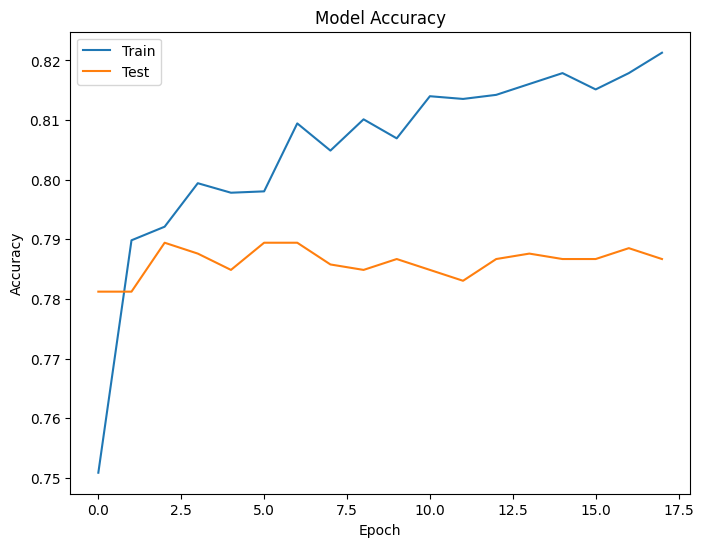

In [58]:
plt.figure(figsize = (8 , 6))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train" , "Test"])
plt.show()

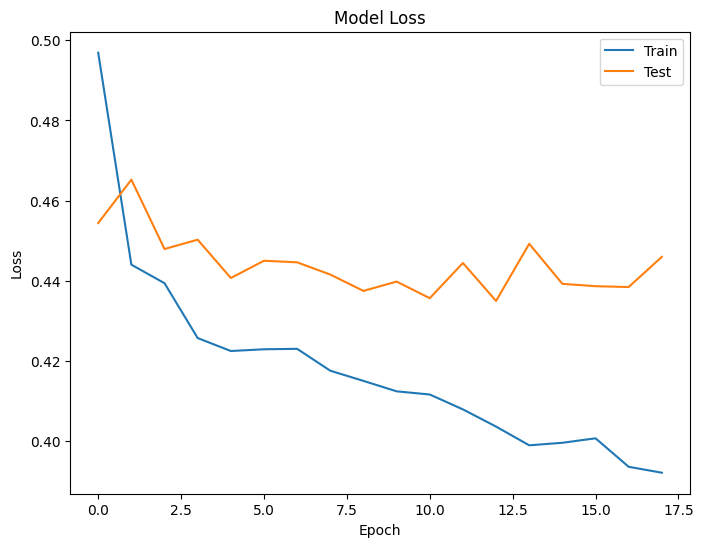

In [59]:
plt.figure(figsize = (8 , 6))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train" , "Test"])
plt.show()

### Evaluation

In [60]:
result = model.evaluate(X_test , y_test , verbose = 0)
print(f"Accuracy : {result[1]} , Loss : {result[0]}")

Accuracy : 0.8087855577468872 , Loss : 0.4246802031993866


In [61]:
print(classification_report(np.argmax(y_test , axis = 1) , np.argmax(model.predict(X_test) , axis = 1)))

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1137
           1       0.67      0.55      0.60       411

    accuracy                           0.81      1548
   macro avg       0.76      0.72      0.74      1548
weighted avg       0.80      0.81      0.80      1548

